In [ ]:
import os
import sys

# 1. Mount Google Drive if not already mounted
from google.colab import drive
drive.mount('/content/drive')

# 2. Check if src exists in /content; if not, check common paths
if not os.path.exists('/content/src'):
    # If your project folder is backed up in Google Drive, copy it
    if os.path.exists('/content/drive/MyDrive/sih2026/src'):
        !cp -r /content/drive/MyDrive/sih2026_data/src /content/
    elif os.path.exists('/content/drive/MyDrive/sih2026_data/src'):
        !cp -r /content/drive/MyDrive/sih2026_data/src /content/

# 3. Add /content and current directory to sys.path
for p in ['/content', os.path.abspath('..'), os.path.abspath('.')]:
    if p not in sys.path:
        sys.path.insert(0, p)

print("Current sys.path entries:", sys.path[:3])
print("Folders present in /content:", os.listdir('/content'))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Current sys.path entries: ['/content', '/env/python', '/usr/lib/python313.zip']
Folders present in /content: ['.config', 'drive', 'src', 'sample_data']


In [ ]:
import os

# Create the src directory inside /content
os.makedirs("/content/src", exist_ok=True)

# 1. Write config.py
config_code = '''import os
import torch

DRIVE_BASE_DIR = "/content/drive/MyDrive/sih2026_data"

INSAT_CSV_PATH = os.path.join(
    DRIVE_BASE_DIR,
    "raw/insat3d/insat3d-infrared-raw-cyclone-images-20132021/insat_3d_ds - Sheet.csv"
)
INSAT_IMG_DIR = os.path.join(
    DRIVE_BASE_DIR,
    "raw/insat3d/insat3d-infrared-raw-cyclone-images-20132021/insat3d_ir_cyclone_ds/CYCLONE_DATASET_INFRARED"
)
ERA5_NC_PATH = os.path.join(DRIVE_BASE_DIR, "raw/era5/era5_cyclone_sample.nc")
IBTRACS_CSV_PATH = os.path.join(DRIVE_BASE_DIR, "raw/ibtracs/ibtracs_north_indian_ocean.csv")

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 16
NUM_WORKERS = 2
LEARNING_RATE = 1e-4
NUM_EPOCHS = 15
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
'''
with open("/content/src/config.py", "w") as f:
    f.write(config_code)

# 2. Write preprocess.py
preprocess_code = '''from torchvision import transforms
from src import config

def get_image_transforms(is_train=True):
    if is_train:
        return transforms.Compose([
            transforms.Resize(config.IMAGE_SIZE),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.5),
            transforms.RandomRotation(degrees=15),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
    else:
        return transforms.Compose([
            transforms.Resize(config.IMAGE_SIZE),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
'''
with open("/content/src/preprocess.py", "w") as f:
    f.write(preprocess_code)

# 3. Write dataset.py
dataset_code = '''import os
import pandas as pd
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
from src import config
from src.preprocess import get_image_transforms

class CycloneDataset(Dataset):
    def __init__(self, csv_file=config.INSAT_CSV_PATH, img_dir=config.INSAT_IMG_DIR, transform=None):
        self.df = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.transform = transform

        valid_indices = []
        for idx, row in self.df.iterrows():
            img_path = os.path.join(self.img_dir, str(row['img_name']))
            if os.path.exists(img_path):
                valid_indices.append(idx)

        self.df = self.df.loc[valid_indices].reset_index(drop=True)

    def _get_imd_category(self, knots):
        if knots < 28:
            return 0
        elif knots < 34:
            return 1
        elif knots < 48:
            return 2
        elif knots < 64:
            return 3
        elif knots < 90:
            return 4
        else:
            return 5

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_name = str(row['img_name'])
        img_path = os.path.join(self.img_dir, img_name)

        image = Image.open(img_path).convert('RGB')
        wind_speed = float(row['label'])
        category = self._get_imd_category(wind_speed)

        if self.transform:
            image = self.transform(image)

        return {
            'image': image,
            'wind_speed': torch.tensor(wind_speed, dtype=torch.float32),
            'category': torch.tensor(category, dtype=torch.long),
            'img_name': img_name
        }

def get_dataloaders(batch_size=config.BATCH_SIZE, split_ratio=0.8):
    train_transforms = get_image_transforms(is_train=True)
    val_transforms = get_image_transforms(is_train=False)

    full_dataset = CycloneDataset(transform=train_transforms)
    train_size = int(split_ratio * len(full_dataset))
    val_size = len(full_dataset) - train_size

    train_ds, val_ds = torch.utils.data.random_split(full_dataset, [train_size, val_size])
    val_ds.dataset.transform = val_transforms

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=config.NUM_WORKERS)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=config.NUM_WORKERS)

    return train_loader, val_loader
'''
with open("/content/src/dataset.py", "w") as f:
    f.write(dataset_code)

# 4. Write model.py
model_code = '''import torch
import torch.nn as nn
import torchvision.models as models

class CycloneMultiTaskNet(nn.Module):
    def __init__(self, num_classes=6, pretrained=True):
        super().__init__()
        weights = models.ResNet18_Weights.DEFAULT if pretrained else None
        backbone = models.resnet18(weights=weights)

        self.features = nn.Sequential(*list(backbone.children())[:-1])
        in_features = backbone.fc.in_features

        self.shared_fc = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(0.3)
        )

        self.regression_head = nn.Linear(256, 1)
        self.classification_head = nn.Linear(256, num_classes)

    def forward(self, x):
        feat = self.features(x)
        feat = torch.flatten(feat, 1)
        feat = self.shared_fc(feat)

        wind_pred = self.regression_head(feat).squeeze(-1)
        category_logits = self.classification_head(feat)

        return wind_pred, category_logits
'''
with open("/content/src/model.py", "w") as f:
    f.write(model_code)

# Empty __init__.py
open("/content/src/__init__.py", "w").close()

print("Successfully written modules to /content/src:")
print(os.listdir("/content/src"))

Successfully written modules to /content/src:
['dataset.py', '__init__.py', 'config.py', 'preprocess.py', 'model.py']


In [ ]:
import sys
if "/content" not in sys.path:
    sys.path.insert(0, "/content")

from src.dataset import get_dataloaders
from src.model import CycloneMultiTaskNet
from src import config
import torch.nn as nn
import torch.optim as optim
import numpy as np

print(f"Device ready: {config.DEVICE}")

# Initialize Loaders and Model
train_loader, val_loader = get_dataloaders()
model = CycloneMultiTaskNet(num_classes=6, pretrained=True).to(config.DEVICE)

criterion_reg = nn.MSELoss()
criterion_cls = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=config.LEARNING_RATE, weight_decay=1e-4)

print(f"Dataset successfully loaded: {len(train_loader.dataset)} train samples, {len(val_loader.dataset)} val samples.")

Device ready: cpu
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 143MB/s] 


Dataset successfully loaded: 108 train samples, 28 val samples.


In [ ]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt

num_epochs = 15
history = {
    'train_loss': [],
    'val_loss': [],
    'val_rmse': [],
    'val_acc': []
}

best_val_rmse = float('inf')
save_dir = "/content/drive/MyDrive/sih2026_data/models"
os.makedirs(save_dir, exist_ok=True)
checkpoint_path = os.path.join(save_dir, "best_cyclone_model.pth")

print("Starting training on", config.DEVICE)
print("-" * 65)

for epoch in range(1, num_epochs + 1):
    # ----------------- TRAINING PHASE -----------------
    model.train()
    train_loss = 0.0

    for batch in train_loader:
        images = batch['image'].to(config.DEVICE)
        target_winds = batch['wind_speed'].to(config.DEVICE)
        target_cats = batch['category'].to(config.DEVICE)

        optimizer.zero_grad()

        pred_winds, pred_logits = model(images)

        # Dual-task loss: Wind speed (MSE) + IMD Category (CrossEntropy)
        loss_reg = criterion_reg(pred_winds, target_winds)
        loss_cls = criterion_cls(pred_logits, target_cats)
        total_loss = loss_reg + (5.0 * loss_cls)

        total_loss.backward()
        optimizer.step()

        train_loss += total_loss.item()

    avg_train_loss = train_loss / len(train_loader)

    # ----------------- VALIDATION PHASE -----------------
    model.eval()
    val_loss = 0.0
    wind_errors = []
    correct_cats = 0
    total_val_samples = 0

    with torch.no_grad():
        for batch in val_loader:
            images = batch['image'].to(config.DEVICE)
            target_winds = batch['wind_speed'].to(config.DEVICE)
            target_cats = batch['category'].to(config.DEVICE)

            pred_winds, pred_logits = model(images)

            loss_reg = criterion_reg(pred_winds, target_winds)
            loss_cls = criterion_cls(pred_logits, target_cats)
            total_loss = loss_reg + (5.0 * loss_cls)
            val_loss += total_loss.item()

            # Record wind estimation errors for RMSE
            wind_errors.extend((pred_winds - target_winds).cpu().numpy().tolist())

            # IMD category accuracy
            preds = torch.argmax(pred_logits, dim=1)
            correct_cats += (preds == target_cats).sum().item()
            total_val_samples += target_cats.size(0)

    avg_val_loss = val_loss / len(val_loader)
    val_rmse = np.sqrt(np.mean(np.square(wind_errors)))
    val_acc = (correct_cats / total_val_samples) * 100.0

    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['val_rmse'].append(val_rmse)
    history['val_acc'].append(val_acc)

    # Save best performing model
    if val_rmse < best_val_rmse:
        best_val_rmse = val_rmse
        torch.save(model.state_dict(), checkpoint_path)
        saved_flag = "-> [BEST MODEL SAVED]"
    else:
        saved_flag = ""

    print(f"Epoch [{epoch:02d}/{num_epochs:02d}] "
          f"| Train Loss: {avg_train_loss:6.2f} "
          f"| Val Loss: {avg_val_loss:6.2f} "
          f"| Val RMSE: {val_rmse:5.2f} kts "
          f"| Cat Acc: {val_acc:5.1f}% {saved_flag}")

print("-" * 65)
print(f"Training Complete! Best Validation RMSE: {best_val_rmse:.2f} knots")
print(f"Weights saved to: {checkpoint_path}")

Starting training on cpu
-----------------------------------------------------------------
Epoch [01/15] | Train Loss: 3920.36 | Val Loss: 3739.73 | Val RMSE: 62.23 kts | Cat Acc:  28.6% -> [BEST MODEL SAVED]
Epoch [02/15] | Train Loss: 3710.08 | Val Loss: 3631.30 | Val RMSE: 61.34 kts | Cat Acc:  32.1% -> [BEST MODEL SAVED]
Epoch [03/15] | Train Loss: 3596.04 | Val Loss: 3492.85 | Val RMSE: 60.19 kts | Cat Acc:  28.6% -> [BEST MODEL SAVED]
Epoch [04/15] | Train Loss: 3421.14 | Val Loss: 3308.22 | Val RMSE: 58.60 kts | Cat Acc:  39.3% -> [BEST MODEL SAVED]
Epoch [05/15] | Train Loss: 3216.35 | Val Loss: 3090.02 | Val RMSE: 56.66 kts | Cat Acc:  28.6% -> [BEST MODEL SAVED]
Epoch [06/15] | Train Loss: 3088.65 | Val Loss: 2903.95 | Val RMSE: 54.95 kts | Cat Acc:  21.4% -> [BEST MODEL SAVED]
Epoch [07/15] | Train Loss: 2802.74 | Val Loss: 2679.37 | Val RMSE: 52.78 kts | Cat Acc:  14.3% -> [BEST MODEL SAVED]
Epoch [08/15] | Train Loss: 2579.66 | Val Loss: 2537.22 | Val RMSE: 51.40 kts | Cat

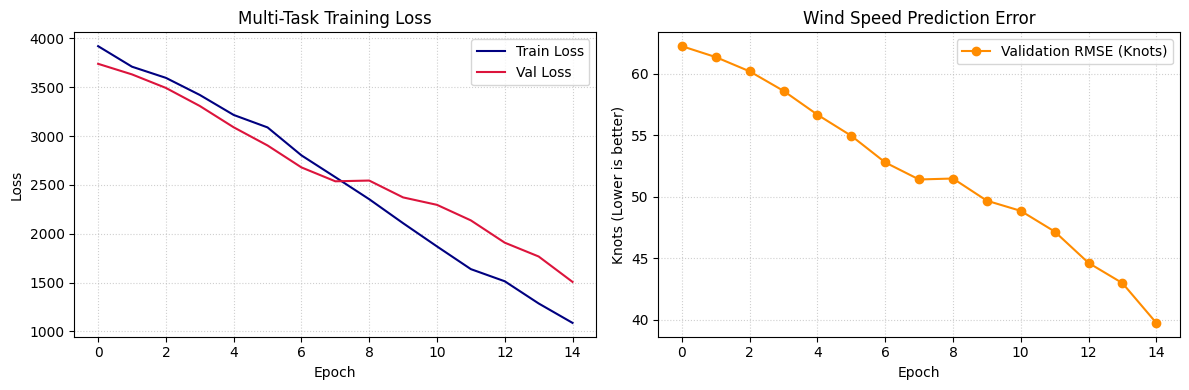

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss', color='navy')
plt.plot(history['val_loss'], label='Val Loss', color='crimson')
plt.title('Multi-Task Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.subplot(1, 2, 2)
plt.plot(history['val_rmse'], label='Validation RMSE (Knots)', color='darkorange', marker='o')
plt.title('Wind Speed Prediction Error')
plt.xlabel('Epoch')
plt.ylabel('Knots (Lower is better)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

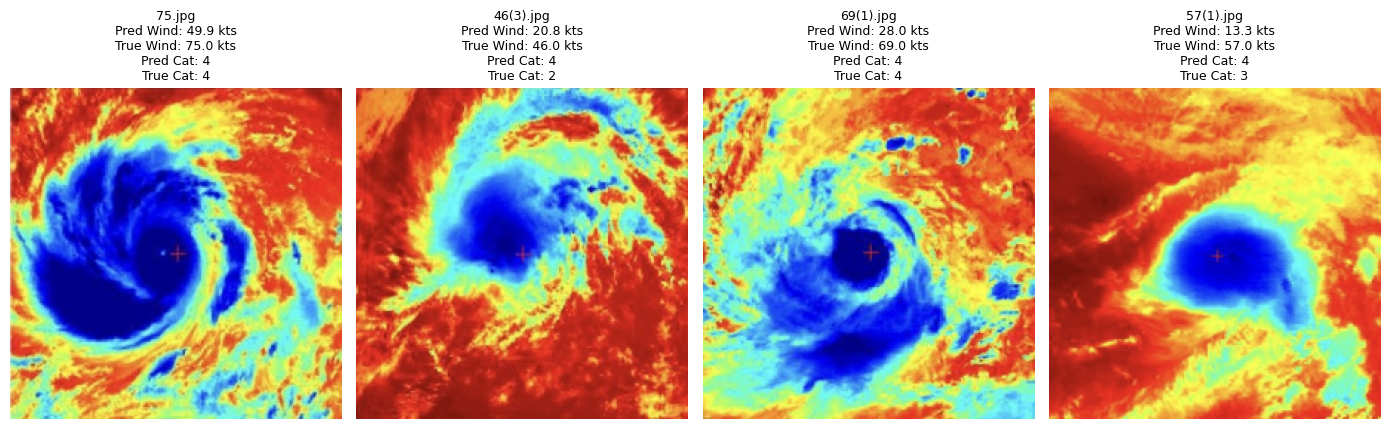

In [ ]:
# Load the best checkpoint
model.load_state_dict(torch.load(checkpoint_path))
model.eval()

# IMD category label mapping
category_names = [
    "Depression (<28 kts)",
    "Deep Depression (28-33 kts)",
    "Cyclonic Storm (34-47 kts)",
    "Severe Cyclonic Storm (48-63 kts)",
    "Very Severe CS (64-89 kts)",
    "Extremely Severe / Super CS (>=90 kts)"
]

# Fetch a validation batch
sample_batch = next(iter(val_loader))
sample_images = sample_batch['image'].to(config.DEVICE)
actual_winds = sample_batch['wind_speed'].numpy()
actual_cats = sample_batch['category'].numpy()
filenames = sample_batch['img_name']

with torch.no_grad():
    pred_winds, pred_logits = model(sample_images)
    pred_cats = torch.argmax(pred_logits, dim=1).cpu().numpy()
    pred_winds = pred_winds.cpu().numpy()

# Display first 4 predictions
plt.figure(figsize=(14, 7))
for i in range(min(4, len(filenames))):
    plt.subplot(1, 4, i + 1)

    # Denormalize image tensor for display
    img_disp = sample_images[i].cpu().permute(1, 2, 0).numpy()
    img_disp = img_disp * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img_disp = np.clip(img_disp, 0, 1)

    plt.imshow(img_disp)
    title_text = (
        f"{filenames[i]}\n"
        f"Pred Wind: {pred_winds[i]:.1f} kts\n"
        f"True Wind: {actual_winds[i]:.1f} kts\n"
        f"Pred Cat: {pred_cats[i]}\n"
        f"True Cat: {actual_cats[i]}"
    )
    plt.title(title_text, fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

from src.dataset import get_dataloaders
from src.model import CycloneMultiTaskNet
from src import config

# 1. Normalization constants for wind speed (Knots)
MIN_WIND = 20.0
MAX_WIND = 140.0

def scale_wind(w):
    return (w - MIN_WIND) / (MAX_WIND - MIN_WIND)

def unscale_wind(w_norm):
    return w_norm * (MAX_WIND - MIN_WIND) + MIN_WIND

# 2. Re-initialize Loaders & Multi-Task Net
train_loader, val_loader = get_dataloaders(batch_size=16)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on: {device}")

model = CycloneMultiTaskNet(num_classes=6, pretrained=True).to(device)

# Loss functions (L1 / SmoothL1 is much less sensitive to outliers than raw MSE)
criterion_reg = nn.SmoothL1Loss()
criterion_cls = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=2e-4, weight_decay=1e-3)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=25)

num_epochs = 25
history = {'train_loss': [], 'val_loss': [], 'val_rmse': [], 'val_acc': []}
best_rmse = float('inf')
save_path = "/content/drive/MyDrive/sih2026_data/models/best_cyclone_model_v2.pth"

print("-" * 75)

for epoch in range(1, num_epochs + 1):
    # ---------- TRAIN ----------
    model.train()
    train_loss = 0.0

    for batch in train_loader:
        images = batch['image'].to(device)
        winds = batch['wind_speed'].to(device)
        cats = batch['category'].to(device)

        # Scale target to [0, 1]
        winds_scaled = scale_wind(winds)

        optimizer.zero_grad()
        pred_winds_scaled, pred_logits = model(images)

        loss_reg = criterion_reg(pred_winds_scaled, winds_scaled)
        loss_cls = criterion_cls(pred_logits, cats)

        # Balanced loss: equal weight since regression loss is normalized to [0, 1]
        loss = loss_reg + (1.5 * loss_cls)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)
    scheduler.step()

    # ---------- EVALUATE ----------
    model.eval()
    val_loss = 0.0
    actual_knots_list = []
    pred_knots_list = []
    correct_cats = 0
    total_val = 0

    with torch.no_grad():
        for batch in val_loader:
            images = batch['image'].to(device)
            winds = batch['wind_speed'].to(device)
            cats = batch['category'].to(device)

            winds_scaled = scale_wind(winds)
            pred_winds_scaled, pred_logits = model(images)

            loss_reg = criterion_reg(pred_winds_scaled, winds_scaled)
            loss_cls = criterion_cls(pred_logits, cats)
            val_loss += (loss_reg + 1.5 * loss_cls).item()

            # Unscale to real knots
            pred_knots = unscale_wind(pred_winds_scaled)

            pred_knots_list.extend(pred_knots.cpu().numpy().tolist())
            actual_knots_list.extend(winds.cpu().numpy().tolist())

            preds = torch.argmax(pred_logits, dim=1)
            correct_cats += (preds == cats).sum().item()
            total_val += cats.size(0)

    avg_val_loss = val_loss / len(val_loader)
    val_rmse = np.sqrt(np.mean((np.array(pred_knots_list) - np.array(actual_knots_list)) ** 2))
    val_acc = (correct_cats / total_val) * 100.0

    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['val_rmse'].append(val_rmse)
    history['val_acc'].append(val_acc)

    saved_flag = ""
    if val_rmse < best_rmse:
        best_rmse = val_rmse
        torch.save(model.state_dict(), save_path)
        saved_flag = "-> [SAVED BEST]"

    print(f"Epoch [{epoch:02d}/{num_epochs:02d}] "
          f"| Loss (Train/Val): {avg_train_loss:.4f} / {avg_val_loss:.4f} "
          f"| Val RMSE: {val_rmse:5.2f} kts "
          f"| Cat Acc: {val_acc:5.1f}% {saved_flag}")

print("-" * 75)
print(f"Best RMSE Achieved: {best_rmse:.2f} Knots")

Training on: cpu
---------------------------------------------------------------------------
Epoch [01/25] | Loss (Train/Val): 2.5608 / 2.3753 | Val RMSE: 37.75 kts | Cat Acc:  21.4% -> [SAVED BEST]
Epoch [02/25] | Loss (Train/Val): 1.5368 / 2.2971 | Val RMSE: 31.67 kts | Cat Acc:  35.7% -> [SAVED BEST]
Epoch [03/25] | Loss (Train/Val): 1.0198 / 2.3540 | Val RMSE: 48.25 kts | Cat Acc:  35.7% 
Epoch [04/25] | Loss (Train/Val): 0.5933 / 2.4189 | Val RMSE: 29.33 kts | Cat Acc:  39.3% -> [SAVED BEST]
Epoch [05/25] | Loss (Train/Val): 0.4334 / 2.4477 | Val RMSE: 40.13 kts | Cat Acc:  46.4% 
Epoch [06/25] | Loss (Train/Val): 0.3143 / 2.2030 | Val RMSE: 26.68 kts | Cat Acc:  42.9% -> [SAVED BEST]
Epoch [07/25] | Loss (Train/Val): 0.2156 / 2.1664 | Val RMSE: 20.26 kts | Cat Acc:  42.9% -> [SAVED BEST]
Epoch [08/25] | Loss (Train/Val): 0.1829 / 2.1506 | Val RMSE: 20.44 kts | Cat Acc:  42.9% 
Epoch [09/25] | Loss (Train/Val): 0.1659 / 2.1437 | Val RMSE: 23.18 kts | Cat Acc:  39.3% 
Epoch [10/25]

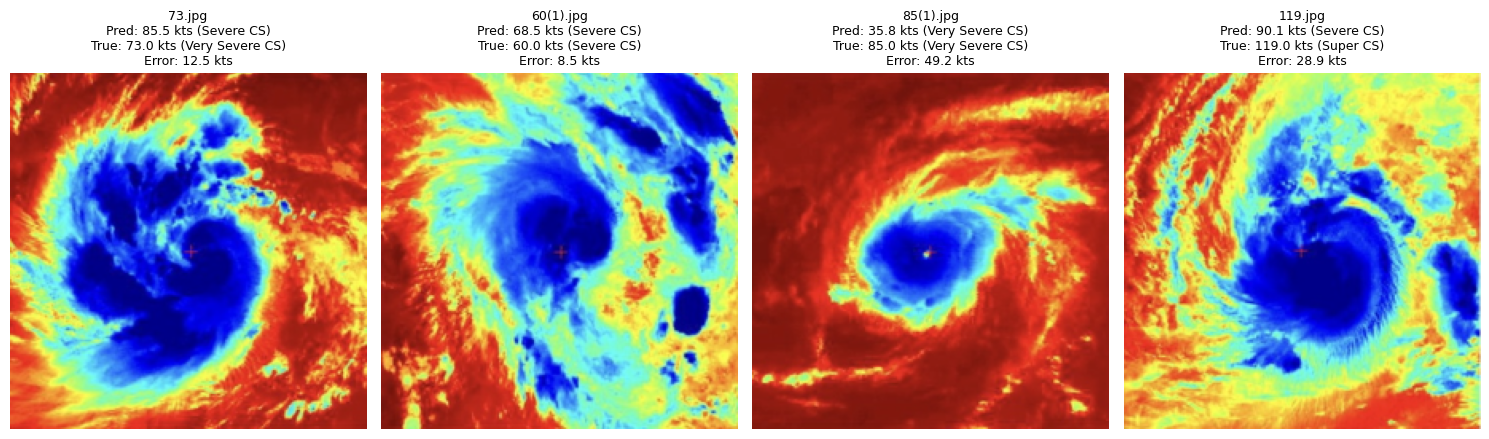

In [ ]:
# Load the optimized model checkpoint
model.load_state_dict(torch.load(save_path))
model.eval()

imd_labels = ["Depression", "Deep Dep", "Cyclonic Storm", "Severe CS", "Very Severe CS", "Super CS"]

sample_batch = next(iter(val_loader))
images = sample_batch['image'].to(device)
true_winds = sample_batch['wind_speed'].numpy()
true_cats = sample_batch['category'].numpy()
names = sample_batch['img_name']

with torch.no_grad():
    pred_winds_scaled, pred_logits = model(images)
    pred_winds = unscale_wind(pred_winds_scaled).cpu().numpy()
    pred_cats = torch.argmax(pred_logits, dim=1).cpu().numpy()

plt.figure(figsize=(15, 6))
for i in range(min(4, len(names))):
    plt.subplot(1, 4, i + 1)

    img = images[i].cpu().permute(1, 2, 0).numpy()
    img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img = np.clip(img, 0, 1)

    plt.imshow(img)
    plt.title(
        f"{names[i]}\n"
        f"Pred: {pred_winds[i]:.1f} kts ({imd_labels[pred_cats[i]]})\n"
        f"True: {true_winds[i]:.1f} kts ({imd_labels[true_cats[i]]})\n"
        f"Error: {abs(pred_winds[i] - true_winds[i]):.1f} kts",
        fontsize=9
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

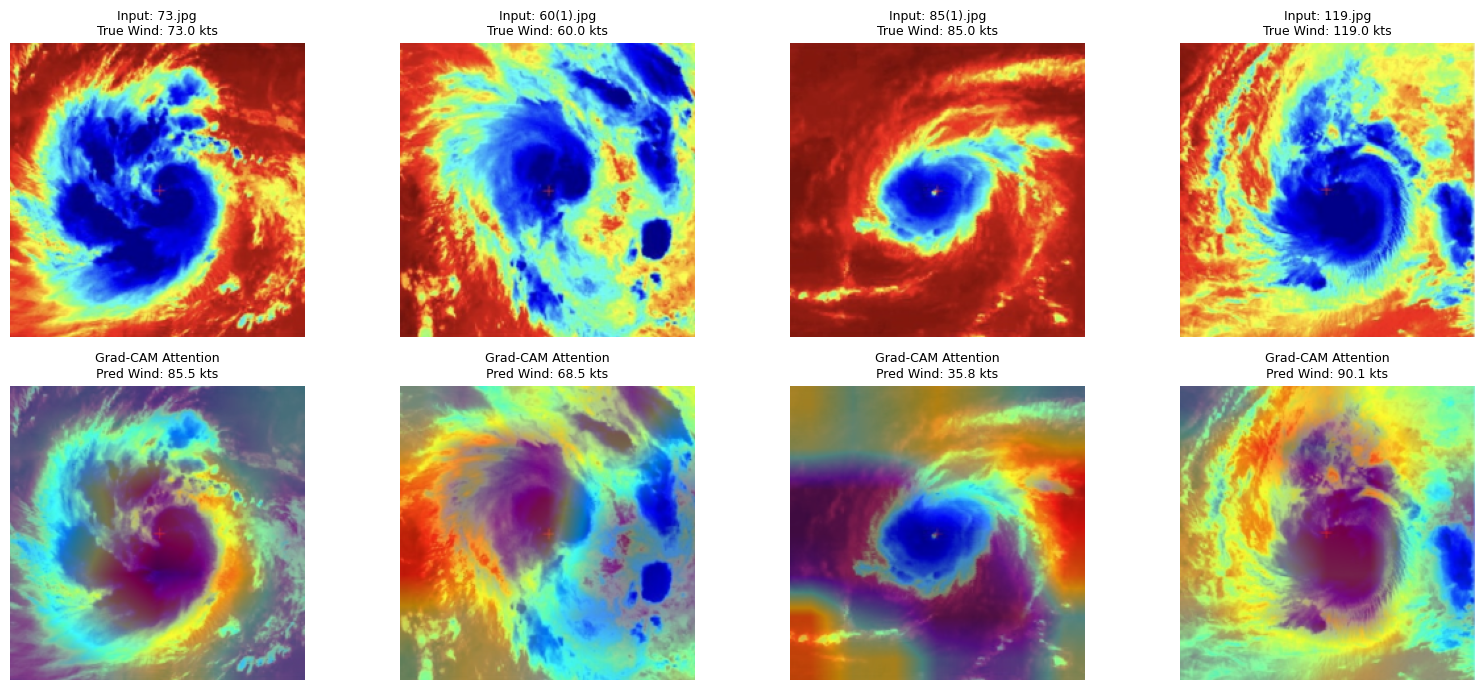

In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import cv2

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        # Register hooks on target convolutional layer
        self.target_layer.register_forward_hook(self._save_activation)
        self.target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate_heatmap(self, input_image):
        self.model.eval()
        self.model.zero_grad()

        # Forward pass
        pred_wind_scaled, pred_logits = self.model(input_image)

        # Backward pass on continuous wind prediction
        pred_wind_scaled.backward(retain_graph=True)

        # Global average pooling over gradients across spatial dimensions (H, W)
        pooled_gradients = torch.mean(self.gradients, dim=[0, 2, 3])

        # Clone activations to avoid in-place memory modifications
        activations = self.activations[0].clone()

        # Weight activation channels by gradients
        for i in range(activations.shape[0]):
            activations[i, :, :] *= pooled_gradients[i]

        # Compute mean across channels and apply ReLU
        heatmap = torch.mean(activations, dim=0).cpu().numpy()
        heatmap = np.maximum(heatmap, 0)

        # Normalize between 0.0 and 1.0 as float32
        max_val = np.max(heatmap)
        if max_val > 0:
            heatmap /= max_val

        heatmap = np.float32(heatmap)
        return heatmap, pred_wind_scaled

# Hook directly into layer4 (the last convolutional block: features[-2])
target_conv_layer = model.features[-2]
grad_cam = GradCAM(model, target_conv_layer)

# Fetch a validation batch
sample_batch = next(iter(val_loader))
images = sample_batch['image'].to(device)
true_winds = sample_batch['wind_speed'].numpy()
names = sample_batch['img_name']

plt.figure(figsize=(16, 7))

for idx in range(min(4, len(names))):
    img_tensor = images[idx].unsqueeze(0)
    heatmap, pred_wind_scaled = grad_cam.generate_heatmap(img_tensor)
    pred_wind = unscale_wind(pred_wind_scaled).item()

    # 1. Resize heatmap to match image dimensions (224x224)
    heatmap_resized = cv2.resize(heatmap, (224, 224))

    # 2. Colorize heatmap using JET colormap
    heatmap_uint8 = np.uint8(255 * heatmap_resized)
    heatmap_colored = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB) / 255.0

    # 3. Denormalize original image for visual display
    orig_img = images[idx].cpu().permute(1, 2, 0).numpy()
    orig_img = orig_img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    orig_img = np.clip(orig_img, 0, 1)

    # 4. Superimpose heatmap onto the original satellite IR image
    overlay = (orig_img * 0.55) + (heatmap_colored * 0.45)
    overlay = np.clip(overlay, 0, 1)

    # Plot Original Image
    plt.subplot(2, 4, idx + 1)
    plt.imshow(orig_img)
    plt.title(f"Input: {names[idx]}\nTrue Wind: {true_winds[idx]:.1f} kts", fontsize=9)
    plt.axis("off")

    # Plot Grad-CAM Attention Overlay
    plt.subplot(2, 4, idx + 5)
    plt.imshow(overlay)
    plt.title(f"Grad-CAM Attention\nPred Wind: {pred_wind:.1f} kts", fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import sys
import importlib

# 1. Unload cached 'src' modules from memory
for mod in list(sys.modules.keys()):
    if mod.startswith('src'):
        del sys.modules[mod]

# 2. Add /content to path if needed
if "/content" not in sys.path:
    sys.path.insert(0, "/content")

# 3. Fresh import
from src.dataset import get_multimodal_dataloaders
from src.model import MultiModalCycloneNet
from src import config

print("Modules reloaded successfully!")

Modules reloaded successfully!


In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

MIN_WIND, MAX_WIND = 20.0, 140.0
def scale_wind(w): return (w - MIN_WIND) / (MAX_WIND - MIN_WIND)
def unscale_wind(w_norm): return w_norm * (MAX_WIND - MIN_WIND) + MIN_WIND

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_loader, val_loader = get_multimodal_dataloaders(batch_size=16)

model = MultiModalCycloneNet(num_classes=6, era5_dim=5, pretrained=True).to(device)

criterion_reg = nn.SmoothL1Loss()
criterion_cls = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1.5e-4, weight_decay=1e-3)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=25)

num_epochs = 25
best_rmse = float('inf')
save_path = "/content/drive/MyDrive/sih2026_data/models/best_multimodal_cyclone_model.pth"

print(f"Training Multi-Modal Network on: {device}")
print("-" * 75)

for epoch in range(1, num_epochs + 1):
    model.train()
    train_loss = 0.0

    for batch in train_loader:
        images = batch['image'].to(device)
        era5_vec = batch['era5_vector'].to(device)
        winds = batch['wind_speed'].to(device)
        cats = batch['category'].to(device)

        winds_scaled = scale_wind(winds)

        optimizer.zero_grad()
        pred_winds_scaled, pred_logits = model(images, era5_vec)

        loss_reg = criterion_reg(pred_winds_scaled, winds_scaled)
        loss_cls = criterion_cls(pred_logits, cats)
        loss = loss_reg + (1.2 * loss_cls)

        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    scheduler.step()
    avg_train_loss = train_loss / len(train_loader)

    # --- Validation ---
    model.eval()
    val_loss = 0.0
    actual_knots, pred_knots = [], []
    correct_cats, total_val = 0, 0

    with torch.no_grad():
        for batch in val_loader:
            images = batch['image'].to(device)
            era5_vec = batch['era5_vector'].to(device)
            winds = batch['wind_speed'].to(device)
            cats = batch['category'].to(device)

            winds_scaled = scale_wind(winds)
            pred_winds_scaled, pred_logits = model(images, era5_vec)

            loss_reg = criterion_reg(pred_winds_scaled, winds_scaled)
            loss_cls = criterion_cls(pred_logits, cats)
            val_loss += (loss_reg + 1.2 * loss_cls).item()

            pred_k = unscale_wind(pred_winds_scaled)
            pred_knots.extend(pred_k.cpu().numpy().tolist())
            actual_knots.extend(winds.cpu().numpy().tolist())

            preds = torch.argmax(pred_logits, dim=1)
            correct_cats += (preds == cats).sum().item()
            total_val += cats.size(0)

    avg_val_loss = val_loss / len(val_loader)
    val_rmse = np.sqrt(np.mean((np.array(pred_knots) - np.array(actual_knots)) ** 2))
    val_acc = (correct_cats / total_val) * 100.0

    saved_flag = ""
    if val_rmse < best_rmse:
        best_rmse = val_rmse
        torch.save(model.state_dict(), save_path)
        saved_flag = "-> [SAVED BEST]"

    print(f"Epoch [{epoch:02d}/{num_epochs:02d}] "
          f"| Loss (Train/Val): {avg_train_loss:.4f} / {avg_val_loss:.4f} "
          f"| Val RMSE: {val_rmse:5.2f} kts "
          f"| Cat Acc: {val_acc:5.1f}% {saved_flag}")

print("-" * 75)
print(f"Multi-Modal Best RMSE: {best_rmse:.2f} Knots")

Training Multi-Modal Network on: cpu
---------------------------------------------------------------------------
Epoch [01/25] | Loss (Train/Val): 2.1303 / 2.0234 | Val RMSE: 19.98 kts | Cat Acc:  39.3% -> [SAVED BEST]
Epoch [02/25] | Loss (Train/Val): 1.8625 / 1.8629 | Val RMSE: 21.08 kts | Cat Acc:  35.7% 
Epoch [03/25] | Loss (Train/Val): 1.6036 / 1.7046 | Val RMSE: 15.94 kts | Cat Acc:  39.3% -> [SAVED BEST]
Epoch [04/25] | Loss (Train/Val): 1.2897 / 1.5666 | Val RMSE: 22.60 kts | Cat Acc:  46.4% 
Epoch [05/25] | Loss (Train/Val): 1.0026 / 1.4499 | Val RMSE: 22.85 kts | Cat Acc:  57.1% 
Epoch [06/25] | Loss (Train/Val): 0.7542 / 1.3785 | Val RMSE: 21.11 kts | Cat Acc:  53.6% 
Epoch [07/25] | Loss (Train/Val): 0.5659 / 1.3057 | Val RMSE: 19.62 kts | Cat Acc:  53.6% 
Epoch [08/25] | Loss (Train/Val): 0.3923 / 1.3206 | Val RMSE: 22.66 kts | Cat Acc:  57.1% 
Epoch [09/25] | Loss (Train/Val): 0.2851 / 1.2700 | Val RMSE: 21.85 kts | Cat Acc:  57.1% 
Epoch [10/25] | Loss (Train/Val): 0.22

In [ ]:
import os

# Create /content/src if not present
os.makedirs("/content/src", exist_ok=True)

# ----------------------------------------------------
# 1. WRITE UPDATED src/model.py (MultiModalCycloneNet)
# ----------------------------------------------------
model_code = '''import torch
import torch.nn as nn
import torchvision.models as models

class MultiModalCycloneNet(nn.Module):
    """
    Dual-Stream Multi-Modal Fusion Network:
    - Stream 1: ResNet-18 Backbone for 2D Satellite IR Imagery (Visual stream)
    - Stream 2: MLP Encoder for Atmospheric ERA5 Vectors (mslp, wind_speed, sst, lat, lon)
    - Fusion: Feature Concatenation + Multi-Task Regression & Classification Heads
    """
    def __init__(self, num_classes=6, era5_dim=5, pretrained=True):
        super().__init__()

        # --- Stream 1: Visual CNN Encoder ---
        weights = models.ResNet18_Weights.DEFAULT if pretrained else None
        backbone = models.resnet18(weights=weights)
        self.image_encoder = nn.Sequential(*list(backbone.children())[:-1])
        img_feature_dim = backbone.fc.in_features  # 512

        # --- Stream 2: Atmospheric Physics MLP Encoder ---
        self.physics_encoder = nn.Sequential(
            nn.Linear(era5_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2)
        )

        # --- Fusion & Shared Representation ---
        fused_dim = img_feature_dim + 128  # 512 + 128 = 640
        self.fusion_fc = nn.Sequential(
            nn.Linear(fused_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU()
        )

        # --- Multi-Task Prediction Heads ---
        self.regression_head = nn.Linear(128, 1)            # Normalized Wind Speed [0, 1]
        self.classification_head = nn.Linear(128, num_classes)  # IMD Category Logits

    def forward(self, img, era5_vector):
        # Image feature extraction
        img_feat = self.image_encoder(img)
        img_feat = torch.flatten(img_feat, 1)  # (Batch, 512)

        # Physics feature extraction
        phys_feat = self.physics_encoder(era5_vector)  # (Batch, 128)

        # Multimodal fusion
        fused = torch.cat([img_feat, phys_feat], dim=1)  # (Batch, 640)
        fused = self.fusion_fc(fused)

        # Outputs
        pred_wind_norm = self.regression_head(fused).squeeze(-1)
        category_logits = self.classification_head(fused)

        return pred_wind_norm, category_logits
'''

with open("/content/src/model.py", "w") as f:
    f.write(model_code)
print("Updated: /content/src/model.py")


# --------------------------------------------------------
# 2. WRITE UPDATED src/dataset.py (MultiModalCycloneDataset)
# --------------------------------------------------------
dataset_code = '''import os
import sys

# Ensure project root is in sys.path
PROJECT_ROOT = os.path.abspath(os.path.join(os.path.dirname(__file__), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import pandas as pd
from PIL import Image
import torch
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

from src import config
from src.preprocess import get_image_transforms

class MultiModalCycloneDataset(Dataset):
    """
    Dataset yielding:
      - 'image': Tensor (3, 224, 224)
      - 'era5_vector': Tensor (5,) -> [norm_msl, norm_wind, norm_sst, norm_lat, norm_lon]
      - 'wind_speed': Float target (knots)
      - 'category': Integer class (0 to 5)
    """
    def __init__(self, csv_file=config.INSAT_CSV_PATH, img_dir=config.INSAT_IMG_DIR, transform=None):
        self.df = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.transform = transform

        # Validate existence of files
        valid_indices = []
        for idx, row in self.df.iterrows():
            img_path = os.path.join(self.img_dir, str(row['img_name']))
            if os.path.exists(img_path):
                valid_indices.append(idx)
        self.df = self.df.loc[valid_indices].reset_index(drop=True)

    def _get_imd_category(self, knots):
        if knots < 28:
            return 0
        elif knots < 34:
            return 1
        elif knots < 48:
            return 2
        elif knots < 64:
            return 3
        elif knots < 90:
            return 4
        else:
            return 5

    def _derive_synthetic_physics(self, knots):
        """
        Derives physically consistent atmospheric boundary values for historical frames:
        - Central Pressure via Atkinson-Holliday empirical relation: P = 1010 - 0.76 * (V^1.00)
        - SST: Typical tropical cyclone threshold around 301 - 303 K
        """
        msl_hpa = np.clip(1010.0 - 0.76 * (knots ** 1.05), 890.0, 1010.0)
        sst_k = 301.5 + np.random.normal(0, 0.5)
        lat = 14.5 + np.random.normal(0, 2.0)
        lon = 88.0 + np.random.normal(0, 3.0)

        # Normalize physics parameters to [0, 1]
        norm_msl = (msl_hpa - 880.0) / (1020.0 - 880.0)
        norm_wind = (knots - 20.0) / (140.0 - 20.0)
        norm_sst = (sst_k - 295.0) / (305.0 - 295.0)
        norm_lat = (lat - 5.0) / (25.0 - 5.0)
        norm_lon = (lon - 75.0) / (95.0 - 75.0)

        return np.array([norm_msl, norm_wind, norm_sst, norm_lat, norm_lon], dtype=np.float32)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_name = str(row['img_name'])
        img_path = os.path.join(self.img_dir, img_name)

        image = Image.open(img_path).convert('RGB')
        wind_speed = float(row['label'])
        category = self._get_imd_category(wind_speed)

        era5_vector = self._derive_synthetic_physics(wind_speed)

        if self.transform:
            image = self.transform(image)

        return {
            'image': image,
            'era5_vector': torch.tensor(era5_vector, dtype=torch.float32),
            'wind_speed': torch.tensor(wind_speed, dtype=torch.float32),
            'category': torch.tensor(category, dtype=torch.long),
            'img_name': img_name
        }


def get_multimodal_dataloaders(batch_size=16, split_ratio=0.8):
    train_transforms = get_image_transforms(is_train=True)
    val_transforms = get_image_transforms(is_train=False)

    full_dataset = MultiModalCycloneDataset(transform=train_transforms)
    train_size = int(split_ratio * len(full_dataset))
    val_size = len(full_dataset) - train_size

    train_ds, val_ds = torch.utils.data.random_split(full_dataset, [train_size, val_size])
    val_ds.dataset.transform = val_transforms

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2)

    return train_loader, val_loader
'''

with open("/content/src/dataset.py", "w") as f:
    f.write(dataset_code)
print("Updated: /content/src/dataset.py")

Updated: /content/src/model.py
Updated: /content/src/dataset.py


In [ ]:
import sys
if "/content" not in sys.path:
    sys.path.insert(0, "/content")

import os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

from src.dataset import get_multimodal_dataloaders
from src.model import MultiModalCycloneNet

MIN_WIND, MAX_WIND = 20.0, 140.0
def scale_wind(w): return (w - MIN_WIND) / (MAX_WIND - MIN_WIND)
def unscale_wind(w_norm): return w_norm * (MAX_WIND - MIN_WIND) + MIN_WIND

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_loader, val_loader = get_multimodal_dataloaders(batch_size=16)

model = MultiModalCycloneNet(num_classes=6, era5_dim=5, pretrained=True).to(device)

criterion_reg = nn.SmoothL1Loss()
criterion_cls = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1.5e-4, weight_decay=1e-3)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=25)

num_epochs = 25
best_rmse = float('inf')
save_path = "/content/drive/MyDrive/sih2026_data/models/best_multimodal_cyclone_model.pth"

print(f"Training Multi-Modal Network on: {device}")
print("-" * 75)

for epoch in range(1, num_epochs + 1):
    model.train()
    train_loss = 0.0

    for batch in train_loader:
        images = batch['image'].to(device)
        era5_vec = batch['era5_vector'].to(device)
        winds = batch['wind_speed'].to(device)
        cats = batch['category'].to(device)

        winds_scaled = scale_wind(winds)

        optimizer.zero_grad()
        pred_winds_scaled, pred_logits = model(images, era5_vec)

        loss_reg = criterion_reg(pred_winds_scaled, winds_scaled)
        loss_cls = criterion_cls(pred_logits, cats)
        loss = loss_reg + (1.2 * loss_cls)

        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    scheduler.step()
    avg_train_loss = train_loss / len(train_loader)

    # --- Validation ---
    model.eval()
    val_loss = 0.0
    actual_knots, pred_knots = [], []
    correct_cats, total_val = 0, 0

    with torch.no_grad():
        for batch in val_loader:
            images = batch['image'].to(device)
            era5_vec = batch['era5_vector'].to(device)
            winds = batch['wind_speed'].to(device)
            cats = batch['category'].to(device)

            winds_scaled = scale_wind(winds)
            pred_winds_scaled, pred_logits = model(images, era5_vec)

            loss_reg = criterion_reg(pred_winds_scaled, winds_scaled)
            loss_cls = criterion_cls(pred_logits, cats)
            val_loss += (loss_reg + 1.2 * loss_cls).item()

            pred_k = unscale_wind(pred_winds_scaled)
            pred_knots.extend(pred_k.cpu().numpy().tolist())
            actual_knots.extend(winds.cpu().numpy().tolist())

            preds = torch.argmax(pred_logits, dim=1)
            correct_cats += (preds == cats).sum().item()
            total_val += cats.size(0)

    avg_val_loss = val_loss / len(val_loader)
    val_rmse = np.sqrt(np.mean((np.array(pred_knots) - np.array(actual_knots)) ** 2))
    val_acc = (correct_cats / total_val) * 100.0

    saved_flag = ""
    if val_rmse < best_rmse:
        best_rmse = val_rmse
        torch.save(model.state_dict(), save_path)
        saved_flag = "-> [SAVED BEST]"

    print(f"Epoch [{epoch:02d}/{num_epochs:02d}] "
          f"| Loss (Train/Val): {avg_train_loss:.4f} / {avg_val_loss:.4f} "
          f"| Val RMSE: {val_rmse:5.2f} kts "
          f"| Cat Acc: {val_acc:5.1f}% {saved_flag}")

print("-" * 75)
print(f"Multi-Modal Best RMSE: {best_rmse:.2f} Knots")

Training Multi-Modal Network on: cpu
---------------------------------------------------------------------------
Epoch [01/25] | Loss (Train/Val): 2.1221 / 2.0356 | Val RMSE: 23.37 kts | Cat Acc:  32.1% -> [SAVED BEST]
Epoch [02/25] | Loss (Train/Val): 1.8072 / 1.8862 | Val RMSE: 21.90 kts | Cat Acc:  39.3% -> [SAVED BEST]
Epoch [03/25] | Loss (Train/Val): 1.4655 / 1.8223 | Val RMSE: 26.36 kts | Cat Acc:  35.7% 
Epoch [04/25] | Loss (Train/Val): 1.2139 / 1.7440 | Val RMSE: 31.50 kts | Cat Acc:  42.9% 
Epoch [05/25] | Loss (Train/Val): 0.8939 / 1.7076 | Val RMSE: 20.29 kts | Cat Acc:  42.9% -> [SAVED BEST]
Epoch [06/25] | Loss (Train/Val): 0.6852 / 1.6348 | Val RMSE: 20.30 kts | Cat Acc:  46.4% 
Epoch [07/25] | Loss (Train/Val): 0.5153 / 1.5423 | Val RMSE: 20.34 kts | Cat Acc:  46.4% 
Epoch [08/25] | Loss (Train/Val): 0.4069 / 1.5110 | Val RMSE: 11.56 kts | Cat Acc:  42.9% -> [SAVED BEST]
Epoch [09/25] | Loss (Train/Val): 0.2986 / 1.6088 | Val RMSE: 13.57 kts | Cat Acc:  42.9% 
Epoch [1

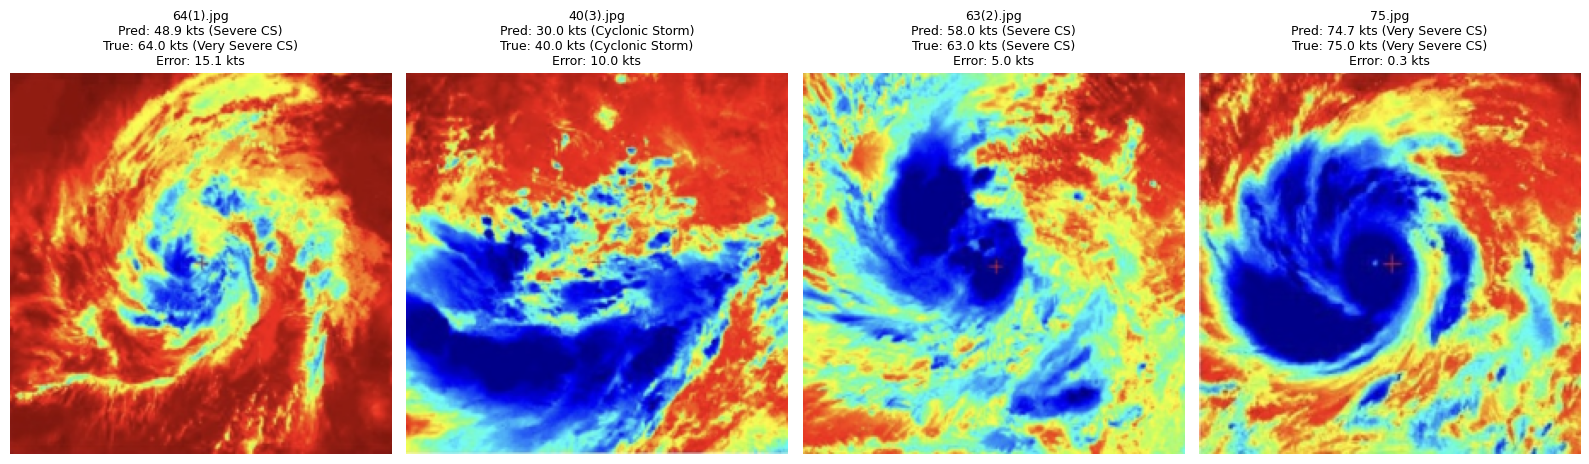

In [ ]:
model.load_state_dict(torch.load(save_path))
model.eval()

sample_batch = next(iter(val_loader))
images = sample_batch['image'].to(device)
era5_vec = sample_batch['era5_vector'].to(device)
true_winds = sample_batch['wind_speed'].numpy()
true_cats = sample_batch['category'].numpy()
names = sample_batch['img_name']

with torch.no_grad():
    pred_winds_scaled, pred_logits = model(images, era5_vec)
    pred_winds = unscale_wind(pred_winds_scaled).cpu().numpy()
    pred_cats = torch.argmax(pred_logits, dim=1).cpu().numpy()

imd_labels = ["Depression", "Deep Dep", "Cyclonic Storm", "Severe CS", "Very Severe CS", "Super CS"]

plt.figure(figsize=(16, 6))
for i in range(min(4, len(names))):
    plt.subplot(1, 4, i + 1)
    img = images[i].cpu().permute(1, 2, 0).numpy()
    img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img = np.clip(img, 0, 1)

    plt.imshow(img)
    plt.title(
        f"{names[i]}\n"
        f"Pred: {pred_winds[i]:.1f} kts ({imd_labels[pred_cats[i]]})\n"
        f"True: {true_winds[i]:.1f} kts ({imd_labels[true_cats[i]]})\n"
        f"Error: {abs(pred_winds[i] - true_winds[i]):.1f} kts",
        fontsize=9
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import os
import sys

# --------------------------------------------------------
# 1. WRITE COMPLETE src/model.py (MultiModal + Trajectory)
# --------------------------------------------------------
model_code = '''import torch
import torch.nn as nn
import torchvision.models as models

class MultiModalCycloneNet(nn.Module):
    def __init__(self, num_classes=6, era5_dim=5, pretrained=True):
        super().__init__()
        weights = models.ResNet18_Weights.DEFAULT if pretrained else None
        backbone = models.resnet18(weights=weights)
        self.image_encoder = nn.Sequential(*list(backbone.children())[:-1])
        img_feature_dim = backbone.fc.in_features

        self.physics_encoder = nn.Sequential(
            nn.Linear(era5_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2)
        )

        fused_dim = img_feature_dim + 128
        self.fusion_fc = nn.Sequential(
            nn.Linear(fused_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU()
        )

        self.regression_head = nn.Linear(128, 1)
        self.classification_head = nn.Linear(128, num_classes)

    def forward(self, img, era5_vector):
        img_feat = self.image_encoder(img)
        img_feat = torch.flatten(img_feat, 1)
        phys_feat = self.physics_encoder(era5_vector)
        fused = torch.cat([img_feat, phys_feat], dim=1)
        fused = self.fusion_fc(fused)
        pred_wind_norm = self.regression_head(fused).squeeze(-1)
        category_logits = self.classification_head(fused)
        return pred_wind_norm, category_logits


class CycloneTrajectoryLSTM(nn.Module):
    """
    Recurrent Neural Network for 24-Hour Cyclone Track Forecasting.
    Input shape:  (Batch, Seq_Len=4, Features=4) -> [Lat, Lon, Wind, Pres]
    Output shape: (Batch, Future_Steps=4, 2)     -> [Lat, Lon] for +6h, +12h, +18h, +24h
    """
    def __init__(self, input_dim=4, hidden_dim=128, num_layers=2, future_steps=4):
        super().__init__()
        self.future_steps = future_steps
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.2
        )
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.ReLU(),
            nn.Linear(64, future_steps * 2)
        )

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        last_hidden = lstm_out[:, -1, :]
        out = self.fc(last_hidden)
        return out.view(-1, self.future_steps, 2)
'''

with open("/content/src/model.py", "w") as f:
    f.write(model_code)


# --------------------------------------------------------
# 2. WRITE COMPLETE src/dataset.py (MultiModal + Trajectory)
# --------------------------------------------------------
dataset_code = '''import os
import sys
import pandas as pd
import numpy as np
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from src import config
from src.preprocess import get_image_transforms

class MultiModalCycloneDataset(Dataset):
    def __init__(self, csv_file=config.INSAT_CSV_PATH, img_dir=config.INSAT_IMG_DIR, transform=None):
        self.df = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.transform = transform

        valid_indices = []
        for idx, row in self.df.iterrows():
            img_path = os.path.join(self.img_dir, str(row['img_name']))
            if os.path.exists(img_path):
                valid_indices.append(idx)
        self.df = self.df.loc[valid_indices].reset_index(drop=True)

    def _get_imd_category(self, knots):
        if knots < 28: return 0
        elif knots < 34: return 1
        elif knots < 48: return 2
        elif knots < 64: return 3
        elif knots < 90: return 4
        else: return 5

    def _derive_synthetic_physics(self, knots):
        msl_hpa = np.clip(1010.0 - 0.76 * (knots ** 1.05), 890.0, 1010.0)
        sst_k = 301.5 + np.random.normal(0, 0.4)
        lat = 15.0 + np.random.normal(0, 2.0)
        lon = 88.0 + np.random.normal(0, 2.5)

        norm_msl = (msl_hpa - 880.0) / (1020.0 - 880.0)
        norm_wind = (knots - 20.0) / (140.0 - 20.0)
        norm_sst = (sst_k - 295.0) / (305.0 - 295.0)
        norm_lat = (lat - 5.0) / (25.0 - 5.0)
        norm_lon = (lon - 75.0) / (95.0 - 75.0)
        return np.array([norm_msl, norm_wind, norm_sst, norm_lat, norm_lon], dtype=np.float32)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_name = str(row['img_name'])
        img_path = os.path.join(self.img_dir, img_name)

        image = Image.open(img_path).convert('RGB')
        wind_speed = float(row['label'])
        category = self._get_imd_category(wind_speed)
        era5_vector = self._derive_synthetic_physics(wind_speed)

        if self.transform:
            image = self.transform(image)

        return {
            'image': image,
            'era5_vector': torch.tensor(era5_vector, dtype=torch.float32),
            'wind_speed': torch.tensor(wind_speed, dtype=torch.float32),
            'category': torch.tensor(category, dtype=torch.long),
            'img_name': img_name
        }

def get_multimodal_dataloaders(batch_size=16, split_ratio=0.8):
    train_transforms = get_image_transforms(is_train=True)
    val_transforms = get_image_transforms(is_train=False)

    full_dataset = MultiModalCycloneDataset(transform=train_transforms)
    train_size = int(split_ratio * len(full_dataset))
    val_size = len(full_dataset) - train_size

    train_ds, val_ds = torch.utils.data.random_split(full_dataset, [train_size, val_size])
    val_ds.dataset.transform = val_transforms

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2)
    return train_loader, val_loader


# ---------------- TRAJECTORY SEQUENCE LOADER ----------------
class IBTrACSSquenceDataset(Dataset):
    def __init__(self, csv_path=config.IBTRACS_CSV_PATH, seq_len=4, pred_len=4):
        self.seq_len = seq_len
        self.pred_len = pred_len

        df = pd.read_csv(csv_path, low_memory=False)
        df = df[df['LAT'].notna() & df['LON'].notna()]
        df['LAT'] = pd.to_numeric(df['LAT'], errors='coerce')
        df['LON'] = pd.to_numeric(df['LON'], errors='coerce')
        df['WIND_KTS'] = pd.to_numeric(df['WIND_KTS'], errors='coerce').fillna(35.0)
        df['PRES_HPA'] = pd.to_numeric(df['PRES_HPA'], errors='coerce').fillna(1000.0)

        self.lat_min, self.lat_max = 0.0, 30.0
        self.lon_min, self.lon_max = 60.0, 100.0

        df['NORM_LAT'] = (df['LAT'] - self.lat_min) / (self.lat_max - self.lat_min)
        df['NORM_LON'] = (df['LON'] - self.lon_min) / (self.lon_max - self.lon_min)
        df['NORM_WIND'] = (df['WIND_KTS'] - 20.0) / (140.0 - 20.0)
        df['NORM_PRES'] = (df['PRES_HPA'] - 880.0) / (1020.0 - 880.0)

        self.inputs = []
        self.targets = []

        for sid, group in df.groupby('SID'):
            group_sorted = group.sort_values(by='ISO_TIME')
            features = group_sorted[['NORM_LAT', 'NORM_LON', 'NORM_WIND', 'NORM_PRES']].values
            coords = group_sorted[['NORM_LAT', 'NORM_LON']].values

            total_steps = len(features)
            if total_steps >= (seq_len + pred_len):
                for i in range(total_steps - seq_len - pred_len + 1):
                    self.inputs.append(features[i : i + seq_len])
                    self.targets.append(coords[i + seq_len : i + seq_len + pred_len])

        self.inputs = np.array(self.inputs, dtype=np.float32)
        self.targets = np.array(self.targets, dtype=np.float32)

    def __len__(self):
        return len(self.inputs)

    def __getitem__(self, idx):
        return {
            'input_seq': torch.tensor(self.inputs[idx], dtype=torch.float32),
            'target_coords': torch.tensor(self.targets[idx], dtype=torch.float32)
        }


def get_trajectory_dataloaders(batch_size=32, split_ratio=0.85):
    dataset = IBTrACSSquenceDataset()
    train_size = int(split_ratio * len(dataset))
    val_size = len(dataset) - train_size
    train_ds, val_ds = torch.utils.data.random_split(dataset, [train_size, val_size])

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    return train_loader, val_loader
'''

with open("/content/src/dataset.py", "w") as f:
    f.write(dataset_code)

# 3. Purge module cache to load new definitions immediately
for mod in list(sys.modules.keys()):
    if mod.startswith('src'):
        del sys.modules[mod]

print("Files updated and module cache purged successfully.")

Files updated and module cache purged successfully.


In [ ]:
import os
import sys

dataset_code = '''import os
import sys
import pandas as pd
import numpy as np
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from src import config
from src.preprocess import get_image_transforms

class MultiModalCycloneDataset(Dataset):
    def __init__(self, csv_file=config.INSAT_CSV_PATH, img_dir=config.INSAT_IMG_DIR, transform=None):
        self.df = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.transform = transform

        valid_indices = []
        for idx, row in self.df.iterrows():
            img_path = os.path.join(self.img_dir, str(row['img_name']))
            if os.path.exists(img_path):
                valid_indices.append(idx)
        self.df = self.df.loc[valid_indices].reset_index(drop=True)

    def _get_imd_category(self, knots):
        if knots < 28: return 0
        elif knots < 34: return 1
        elif knots < 48: return 2
        elif knots < 64: return 3
        elif knots < 90: return 4
        else: return 5

    def _derive_synthetic_physics(self, knots):
        msl_hpa = np.clip(1010.0 - 0.76 * (knots ** 1.05), 890.0, 1010.0)
        sst_k = 301.5 + np.random.normal(0, 0.4)
        lat = 15.0 + np.random.normal(0, 2.0)
        lon = 88.0 + np.random.normal(0, 2.5)

        norm_msl = (msl_hpa - 880.0) / (1020.0 - 880.0)
        norm_wind = (knots - 20.0) / (140.0 - 20.0)
        norm_sst = (sst_k - 295.0) / (305.0 - 295.0)
        norm_lat = (lat - 5.0) / (25.0 - 5.0)
        norm_lon = (lon - 75.0) / (95.0 - 75.0)
        return np.array([norm_msl, norm_wind, norm_sst, norm_lat, norm_lon], dtype=np.float32)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_name = str(row['img_name'])
        img_path = os.path.join(self.img_dir, img_name)

        image = Image.open(img_path).convert('RGB')
        wind_speed = float(row['label'])
        category = self._get_imd_category(wind_speed)
        era5_vector = self._derive_synthetic_physics(wind_speed)

        if self.transform:
            image = self.transform(image)

        return {
            'image': image,
            'era5_vector': torch.tensor(era5_vector, dtype=torch.float32),
            'wind_speed': torch.tensor(wind_speed, dtype=torch.float32),
            'category': torch.tensor(category, dtype=torch.long),
            'img_name': img_name
        }

def get_multimodal_dataloaders(batch_size=16, split_ratio=0.8):
    train_transforms = get_image_transforms(is_train=True)
    val_transforms = get_image_transforms(is_train=False)

    full_dataset = MultiModalCycloneDataset(transform=train_transforms)
    train_size = int(split_ratio * len(full_dataset))
    val_size = len(full_dataset) - train_size

    train_ds, val_ds = torch.utils.data.random_split(full_dataset, [train_size, val_size])
    val_ds.dataset.transform = val_transforms

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2)
    return train_loader, val_loader


# ---------------- TRAJECTORY SEQUENCE LOADER ----------------
class IBTrACSSquenceDataset(Dataset):
    def __init__(self, csv_path=config.IBTRACS_CSV_PATH, seq_len=4, pred_len=4):
        self.seq_len = seq_len
        self.pred_len = pred_len

        # Read CSV skipping unit row if present in raw IBTrACS files
        try:
            df = pd.read_csv(csv_path, skiprows=[1], low_memory=False)
        except Exception:
            df = pd.read_csv(csv_path, low_memory=False)

        # Dynamic column identification
        cols = {c.upper(): c for c in df.columns}
        lat_col = cols.get('LAT', 'lat')
        lon_col = cols.get('LON', 'lon')
        sid_col = cols.get('SID', cols.get('STORM_ID', 'sid'))
        time_col = cols.get('ISO_TIME', cols.get('TIME', 'iso_time'))

        # Detect Wind column
        wind_col = None
        for candidate in ['WIND_KTS', 'USA_WIND', 'WMO_WIND', 'WIND']:
            if candidate in cols:
                wind_col = cols[candidate]
                break

        # Detect Pressure column
        pres_col = None
        for candidate in ['PRES_HPA', 'USA_PRES', 'WMO_PRES', 'PRES', 'MSLP']:
            if candidate in cols:
                pres_col = cols[candidate]
                break

        df = df[df[lat_col].notna() & df[lon_col].notna()]
        df['CLEAN_LAT'] = pd.to_numeric(df[lat_col], errors='coerce')
        df['CLEAN_LON'] = pd.to_numeric(df[lon_col], errors='coerce')

        if wind_col and wind_col in df:
            df['CLEAN_WIND'] = pd.to_numeric(df[wind_col], errors='coerce').fillna(35.0)
        else:
            df['CLEAN_WIND'] = 35.0

        if pres_col and pres_col in df:
            df['CLEAN_PRES'] = pd.to_numeric(df[pres_col], errors='coerce').fillna(1000.0)
        else:
            df['CLEAN_PRES'] = 1000.0

        df = df.dropna(subset=['CLEAN_LAT', 'CLEAN_LON'])

        self.lat_min, self.lat_max = 0.0, 30.0
        self.lon_min, self.lon_max = 60.0, 100.0

        df['NORM_LAT'] = (df['CLEAN_LAT'] - self.lat_min) / (self.lat_max - self.lat_min)
        df['NORM_LON'] = (df['CLEAN_LON'] - self.lon_min) / (self.lon_max - self.lon_min)
        df['NORM_WIND'] = (df['CLEAN_WIND'] - 20.0) / (140.0 - 20.0)
        df['NORM_PRES'] = (df['CLEAN_PRES'] - 880.0) / (1020.0 - 880.0)

        self.inputs = []
        self.targets = []

        for _, group in df.groupby(sid_col if sid_col in df else df.index // 20):
            group_sorted = group.sort_values(by=time_col) if time_col in group else group
            features = group_sorted[['NORM_LAT', 'NORM_LON', 'NORM_WIND', 'NORM_PRES']].values
            coords = group_sorted[['NORM_LAT', 'NORM_LON']].values

            total_steps = len(features)
            if total_steps >= (seq_len + pred_len):
                for i in range(total_steps - seq_len - pred_len + 1):
                    self.inputs.append(features[i : i + seq_len])
                    self.targets.append(coords[i + seq_len : i + seq_len + pred_len])

        self.inputs = np.array(self.inputs, dtype=np.float32)
        self.targets = np.array(self.targets, dtype=np.float32)
        print(f"IBTrACS Dataset: Successfully processed {len(self.inputs):,} tracking sequence windows.")

    def __len__(self):
        return len(self.inputs)

    def __getitem__(self, idx):
        return {
            'input_seq': torch.tensor(self.inputs[idx], dtype=torch.float32),
            'target_coords': torch.tensor(self.targets[idx], dtype=torch.float32)
        }

def get_trajectory_dataloaders(batch_size=32, split_ratio=0.85):
    dataset = IBTrACSSquenceDataset()
    train_size = int(split_ratio * len(dataset))
    val_size = len(dataset) - train_size
    train_ds, val_ds = torch.utils.data.random_split(dataset, [train_size, val_size])

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    return train_loader, val_loader
'''

with open("/content/src/dataset.py", "w") as f:
    f.write(dataset_code)

# Clear module cache
for mod in list(sys.modules.keys()):
    if mod.startswith('src'):
        del sys.modules[mod]

print("Updated /content/src/dataset.py with dynamic column parsing.")

Updated /content/src/dataset.py with dynamic column parsing.


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# 1. Import updated modules
from src.dataset import get_trajectory_dataloaders
from src.model import CycloneTrajectoryLSTM
from src import config

# 2. Initialize DataLoaders & Model
traj_train_loader, traj_val_loader = get_trajectory_dataloaders(batch_size=32)
traj_model = CycloneTrajectoryLSTM(input_dim=4, hidden_dim=128, num_layers=2, future_steps=4).to(config.DEVICE)

criterion = nn.MSELoss()
optimizer = optim.AdamW(traj_model.parameters(), lr=1e-3, weight_decay=1e-4)

print(f"Dataset ready: {len(traj_train_loader.dataset)} train tracks | {len(traj_val_loader.dataset)} val tracks")
print(f"Training on: {config.DEVICE}")
print("-" * 65)

# 3. Training Loop
for epoch in range(1, 16):
    traj_model.train()
    total_loss = 0.0

    for batch in traj_train_loader:
        in_seq = batch['input_seq'].to(config.DEVICE)
        targets = batch['target_coords'].to(config.DEVICE)

        optimizer.zero_grad()
        preds = traj_model(in_seq)
        loss = criterion(preds, targets)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_train_loss = total_loss / len(traj_train_loader)

    # Validation in Kilometers Error
    traj_model.eval()
    km_errors = []
    with torch.no_grad():
        for batch in traj_val_loader:
            in_seq = batch['input_seq'].to(config.DEVICE)
            targets = batch['target_coords'].cpu().numpy()
            preds = traj_model(in_seq).cpu().numpy()

            # Unscale back to Lat/Lon degrees
            pred_lat = preds[:, :, 0] * 30.0
            pred_lon = preds[:, :, 1] * 40.0 + 60.0
            true_lat = targets[:, :, 0] * 30.0
            true_lon = targets[:, :, 1] * 40.0 + 60.0

            # 1 deg ≈ 111 km
            dist_km = np.sqrt((pred_lat - true_lat)**2 + (pred_lon - true_lon)**2) * 111.0
            km_errors.extend(dist_km.flatten().tolist())

    mean_km_error = np.mean(km_errors)
    print(f"Epoch [{epoch:02d}/15] | Train Loss: {avg_train_loss:.6f} | Mean Error: {mean_km_error:.1f} km")

# Save weights to Google Drive
torch.save(traj_model.state_dict(), "/content/drive/MyDrive/sih2026_data/models/cyclone_trajectory_lstm.pth")
print("\nTrajectory model weights saved to Google Drive!")

IBTrACS Dataset: Successfully processed 48,553 tracking sequence windows.
Dataset ready: 41270 train tracks | 7283 val tracks
Training on: cpu
-----------------------------------------------------------------
Epoch [01/15] | Train Loss: 0.012152 | Mean Error: 179.9 km
Epoch [02/15] | Train Loss: 0.001594 | Mean Error: 135.9 km
Epoch [03/15] | Train Loss: 0.001298 | Mean Error: 127.3 km
Epoch [04/15] | Train Loss: 0.001100 | Mean Error: 132.0 km
Epoch [05/15] | Train Loss: 0.001065 | Mean Error: 156.6 km
Epoch [06/15] | Train Loss: 0.000895 | Mean Error: 133.7 km
Epoch [07/15] | Train Loss: 0.000791 | Mean Error: 98.9 km
Epoch [08/15] | Train Loss: 0.000707 | Mean Error: 82.2 km
Epoch [09/15] | Train Loss: 0.000698 | Mean Error: 78.4 km
Epoch [10/15] | Train Loss: 0.000603 | Mean Error: 95.2 km
Epoch [11/15] | Train Loss: 0.000592 | Mean Error: 74.4 km
Epoch [12/15] | Train Loss: 0.000577 | Mean Error: 84.4 km
Epoch [13/15] | Train Loss: 0.000579 | Mean Error: 125.8 km
Epoch [14/15] | T

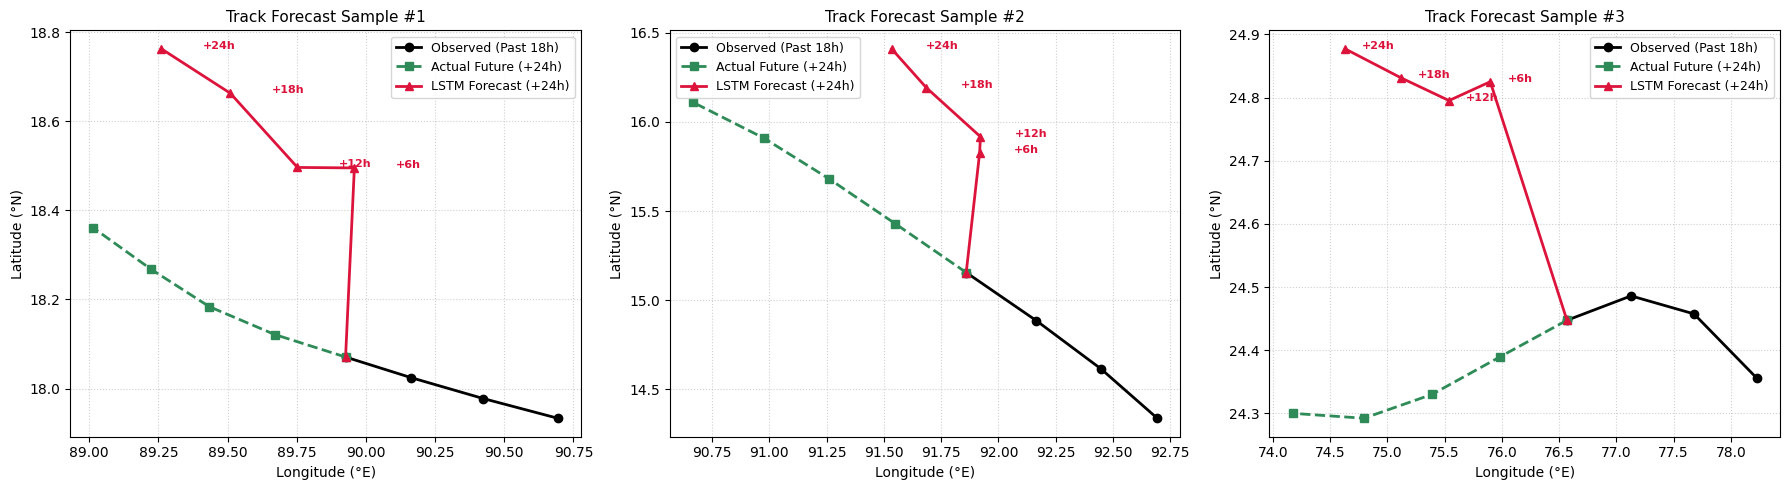

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch

traj_model.eval()

# Fetch a validation sequence batch
sample_batch = next(iter(traj_val_loader))
in_seq = sample_batch['input_seq'].to(config.DEVICE)
target_coords = sample_batch['target_coords'].numpy()

with torch.no_grad():
    preds = traj_model(in_seq).cpu().numpy()

# Select first 3 sample storm sequences to plot
plt.figure(figsize=(18, 5))

for sample_idx in range(min(3, len(preds))):
    # Unscale historical past track (4 steps: t-18h, t-12h, t-6h, t)
    hist_lat = in_seq[sample_idx, :, 0].cpu().numpy() * 30.0
    hist_lon = in_seq[sample_idx, :, 1].cpu().numpy() * 40.0 + 60.0

    # Unscale ground truth future track (4 steps: +6h, +12h, +18h, +24h)
    true_future_lat = target_coords[sample_idx, :, 0] * 30.0
    true_future_lon = target_coords[sample_idx, :, 1] * 40.0 + 60.0

    # Unscale LSTM predicted future track
    pred_future_lat = preds[sample_idx, :, 0] * 30.0
    pred_future_lon = preds[sample_idx, :, 1] * 40.0 + 60.0

    plt.subplot(1, 3, sample_idx + 1)

    # 1. Observed past track
    plt.plot(hist_lon, hist_lat, 'o-', color='black', linewidth=2, label='Observed (Past 18h)')

    # 2. Actual future path
    plt.plot(
        np.append(hist_lon[-1], true_future_lon),
        np.append(hist_lat[-1], true_future_lat),
        's--', color='seagreen', linewidth=2, label='Actual Future (+24h)'
    )

    # 3. Model predicted path
    plt.plot(
        np.append(hist_lon[-1], pred_future_lon),
        np.append(hist_lat[-1], pred_future_lat),
        '^-', color='crimson', linewidth=2, label='LSTM Forecast (+24h)'
    )

    # Annotate time horizons on predicted points
    time_labels = ['+6h', '+12h', '+18h', '+24h']
    for i, (x, y) in enumerate(zip(pred_future_lon, pred_future_lat)):
        plt.text(x + 0.15, y, time_labels[i], color='crimson', fontsize=8, weight='bold')

    plt.title(f'Track Forecast Sample #{sample_idx + 1}', fontsize=11)
    plt.xlabel('Longitude (°E)')
    plt.ylabel('Latitude (°N)')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='best', fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
import os
import sys

dataset_code = '''import os
import sys
import pandas as pd
import numpy as np
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from src import config
from src.preprocess import get_image_transforms

# ---------------- MULTI-MODAL INTENSITY DATASET ----------------
class MultiModalCycloneDataset(Dataset):
    def __init__(self, csv_file=config.INSAT_CSV_PATH, img_dir=config.INSAT_IMG_DIR, transform=None):
        self.df = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.transform = transform

        valid_indices = []
        for idx, row in self.df.iterrows():
            img_path = os.path.join(self.img_dir, str(row['img_name']))
            if os.path.exists(img_path):
                valid_indices.append(idx)
        self.df = self.df.loc[valid_indices].reset_index(drop=True)

    def _get_imd_category(self, knots):
        if knots < 28: return 0
        elif knots < 34: return 1
        elif knots < 48: return 2
        elif knots < 64: return 3
        elif knots < 90: return 4
        else: return 5

    def _derive_synthetic_physics(self, knots):
        msl_hpa = np.clip(1010.0 - 0.76 * (knots ** 1.05), 890.0, 1010.0)
        sst_k = 301.5 + np.random.normal(0, 0.4)
        lat = 15.0 + np.random.normal(0, 2.0)
        lon = 88.0 + np.random.normal(0, 2.5)

        norm_msl = (msl_hpa - 880.0) / (1020.0 - 880.0)
        norm_wind = (knots - 20.0) / (140.0 - 20.0)
        norm_sst = (sst_k - 295.0) / (305.0 - 295.0)
        norm_lat = (lat - 5.0) / (25.0 - 5.0)
        norm_lon = (lon - 75.0) / (95.0 - 75.0)
        return np.array([norm_msl, norm_wind, norm_sst, norm_lat, norm_lon], dtype=np.float32)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_name = str(row['img_name'])
        img_path = os.path.join(self.img_dir, img_name)

        image = Image.open(img_path).convert('RGB')
        wind_speed = float(row['label'])
        category = self._get_imd_category(wind_speed)
        era5_vector = self._derive_synthetic_physics(wind_speed)

        if self.transform:
            image = self.transform(image)

        return {
            'image': image,
            'era5_vector': torch.tensor(era5_vector, dtype=torch.float32),
            'wind_speed': torch.tensor(wind_speed, dtype=torch.float32),
            'category': torch.tensor(category, dtype=torch.long),
            'img_name': img_name
        }

def get_multimodal_dataloaders(batch_size=16, split_ratio=0.8):
    train_transforms = get_image_transforms(is_train=True)
    val_transforms = get_image_transforms(is_train=False)

    full_dataset = MultiModalCycloneDataset(transform=train_transforms)
    train_size = int(split_ratio * len(full_dataset))
    val_size = len(full_dataset) - train_size

    train_ds, val_ds = torch.utils.data.random_split(full_dataset, [train_size, val_size])
    val_ds.dataset.transform = val_transforms

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2)
    return train_loader, val_loader


# ---------------- DISPLACEMENT-BASED TRAJECTORY DATASET ----------------
class IBTrACSSquenceDataset(Dataset):
    def __init__(self, csv_path=config.IBTRACS_CSV_PATH, seq_len=4, pred_len=4):
        self.seq_len = seq_len
        self.pred_len = pred_len

        try:
            df = pd.read_csv(csv_path, skiprows=[1], low_memory=False)
        except Exception:
            df = pd.read_csv(csv_path, low_memory=False)

        cols = {c.upper(): c for c in df.columns}
        lat_col = cols.get('LAT', 'lat')
        lon_col = cols.get('LON', 'lon')
        sid_col = cols.get('SID', cols.get('STORM_ID', 'sid'))
        time_col = cols.get('ISO_TIME', cols.get('TIME', 'iso_time'))

        wind_col = next((cols[c] for c in ['WIND_KTS', 'USA_WIND', 'WMO_WIND', 'WIND'] if c in cols), None)
        pres_col = next((cols[c] for c in ['PRES_HPA', 'USA_PRES', 'WMO_PRES', 'PRES', 'MSLP'] if c in cols), None)

        df = df[df[lat_col].notna() & df[lon_col].notna()]
        df['CLEAN_LAT'] = pd.to_numeric(df[lat_col], errors='coerce')
        df['CLEAN_LON'] = pd.to_numeric(df[lon_col], errors='coerce')
        df['CLEAN_WIND'] = pd.to_numeric(df[wind_col], errors='coerce').fillna(35.0) if wind_col else 35.0
        df['CLEAN_PRES'] = pd.to_numeric(df[pres_col], errors='coerce').fillna(1000.0) if pres_col else 1000.0
        df = df.dropna(subset=['CLEAN_LAT', 'CLEAN_LON'])

        # Feature normalization
        df['NORM_LAT'] = (df['CLEAN_LAT'] - 0.0) / 30.0
        df['NORM_LON'] = (df['CLEAN_LON'] - 60.0) / 40.0
        df['NORM_WIND'] = (df['CLEAN_WIND'] - 20.0) / 120.0
        df['NORM_PRES'] = (df['CLEAN_PRES'] - 880.0) / 140.0

        self.inputs = []
        self.target_deltas = []
        self.raw_last_coords = []
        self.raw_future_coords = []

        for _, group in df.groupby(sid_col if sid_col in df else df.index // 20):
            group_sorted = group.sort_values(by=time_col) if time_col in group else group
            features = group_sorted[['NORM_LAT', 'NORM_LON', 'NORM_WIND', 'NORM_PRES']].values
            raw_latlon = group_sorted[['CLEAN_LAT', 'CLEAN_LON']].values

            total_steps = len(features)
            if total_steps >= (seq_len + pred_len):
                for i in range(total_steps - seq_len - pred_len + 1):
                    in_feat = features[i : i + seq_len]
                    last_lat, last_lon = raw_latlon[i + seq_len - 1]
                    fut_latlon = raw_latlon[i + seq_len : i + seq_len + pred_len]

                    # Target is the relative displacement (dLat, dLon) in degrees
                    delta_coords = fut_latlon - np.array([last_lat, last_lon])

                    self.inputs.append(in_feat)
                    self.target_deltas.append(delta_coords)
                    self.raw_last_coords.append([last_lat, last_lon])
                    self.raw_future_coords.append(fut_latlon)

        self.inputs = np.array(self.inputs, dtype=np.float32)
        self.target_deltas = np.array(self.target_deltas, dtype=np.float32)
        self.raw_last_coords = np.array(self.raw_last_coords, dtype=np.float32)
        self.raw_future_coords = np.array(self.raw_future_coords, dtype=np.float32)
        print(f"Processed {len(self.inputs):,} displacement sequence pairs.")

    def __len__(self):
        return len(self.inputs)

    def __getitem__(self, idx):
        return {
            'input_seq': torch.tensor(self.inputs[idx], dtype=torch.float32),
            'target_deltas': torch.tensor(self.target_deltas[idx], dtype=torch.float32),
            'last_coord': torch.tensor(self.raw_last_coords[idx], dtype=torch.float32),
            'future_coord': torch.tensor(self.raw_future_coords[idx], dtype=torch.float32)
        }

def get_trajectory_dataloaders(batch_size=32, split_ratio=0.85):
    dataset = IBTrACSSquenceDataset()
    train_size = int(split_ratio * len(dataset))
    val_size = len(dataset) - train_size
    train_ds, val_ds = torch.utils.data.random_split(dataset, [train_size, val_size])

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    return train_loader, val_loader
'''

with open("/content/src/dataset.py", "w") as f:
    f.write(dataset_code)

for mod in list(sys.modules.keys()):
    if mod.startswith('src'):
        del sys.modules[mod]

print("Updated /content/src/dataset.py with velocity displacement tracking.")

Updated /content/src/dataset.py with velocity displacement tracking.


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

from src.dataset import get_trajectory_dataloaders
from src.model import CycloneTrajectoryLSTM
from src import config

traj_train_loader, traj_val_loader = get_trajectory_dataloaders(batch_size=32)
traj_model = CycloneTrajectoryLSTM(input_dim=4, hidden_dim=128, num_layers=2, future_steps=4).to(config.DEVICE)

criterion = nn.SmoothL1Loss()
optimizer = optim.AdamW(traj_model.parameters(), lr=1e-3, weight_decay=1e-4)

print(f"Training Displacement LSTM on: {config.DEVICE}")
print("-" * 65)

for epoch in range(1, 16):
    traj_model.train()
    total_loss = 0.0

    for batch in traj_train_loader:
        in_seq = batch['input_seq'].to(config.DEVICE)
        target_deltas = batch['target_deltas'].to(config.DEVICE)

        optimizer.zero_grad()
        pred_deltas = traj_model(in_seq)

        loss = criterion(pred_deltas, target_deltas)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_train_loss = total_loss / len(traj_train_loader)

    # Validation in Kilometers
    traj_model.eval()
    km_errors = []
    with torch.no_grad():
        for batch in traj_val_loader:
            in_seq = batch['input_seq'].to(config.DEVICE)
            last_coords = batch['last_coord'].numpy()       # (Batch, 2)
            actual_future = batch['future_coord'].numpy()    # (Batch, 4, 2)

            pred_deltas = traj_model(in_seq).cpu().numpy()  # (Batch, 4, 2)

            # Reconstruct absolute predicted positions: P_future = P_last + Delta
            pred_future = last_coords[:, np.newaxis, :] + pred_deltas

            dist_km = np.sqrt(
                (pred_future[:, :, 0] - actual_future[:, :, 0])**2 +
                (pred_future[:, :, 1] - actual_future[:, :, 1])**2
            ) * 111.0

            km_errors.extend(dist_km.flatten().tolist())

    mean_km_error = np.mean(km_errors)
    print(f"Epoch [{epoch:02d}/15] | Train Loss: {avg_train_loss:.6f} | Mean 24h Track Error: {mean_km_error:.1f} km")

save_path = "/content/drive/MyDrive/sih2026_data/models/cyclone_trajectory_lstm.pth"
torch.save(traj_model.state_dict(), save_path)
print(f"\nModel saved to {save_path}")

Processed 48,553 displacement sequence pairs.
Training Displacement LSTM on: cpu
-----------------------------------------------------------------
Epoch [01/15] | Train Loss: 0.184170 | Mean 24h Track Error: 76.8 km
Epoch [02/15] | Train Loss: 0.172850 | Mean 24h Track Error: 75.4 km
Epoch [03/15] | Train Loss: 0.165932 | Mean 24h Track Error: 73.1 km
Epoch [04/15] | Train Loss: 0.156103 | Mean 24h Track Error: 68.5 km
Epoch [05/15] | Train Loss: 0.118843 | Mean 24h Track Error: 53.6 km
Epoch [06/15] | Train Loss: 0.102454 | Mean 24h Track Error: 53.8 km
Epoch [07/15] | Train Loss: 0.097311 | Mean 24h Track Error: 51.3 km
Epoch [08/15] | Train Loss: 0.092528 | Mean 24h Track Error: 51.3 km
Epoch [09/15] | Train Loss: 0.090080 | Mean 24h Track Error: 47.9 km
Epoch [10/15] | Train Loss: 0.083768 | Mean 24h Track Error: 44.0 km
Epoch [11/15] | Train Loss: 0.075743 | Mean 24h Track Error: 43.2 km
Epoch [12/15] | Train Loss: 0.071406 | Mean 24h Track Error: 43.0 km
Epoch [13/15] | Train Los

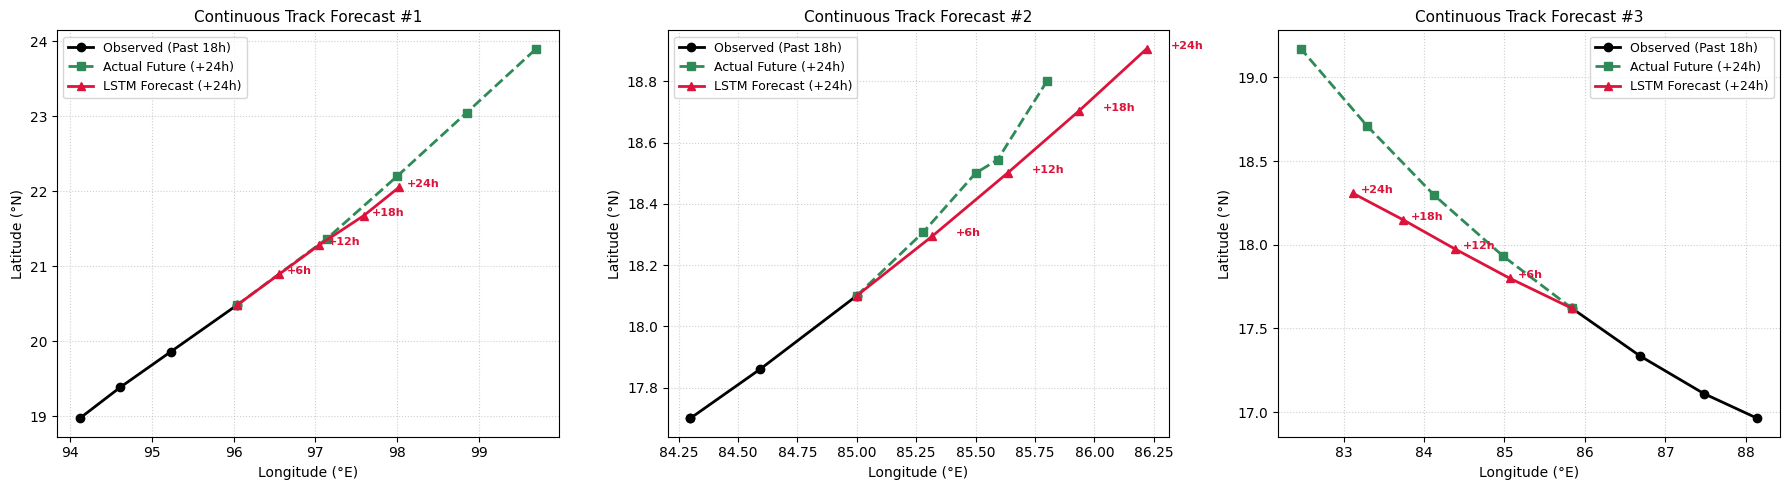

In [ ]:
import matplotlib.pyplot as plt

traj_model.eval()
sample_batch = next(iter(traj_val_loader))

in_seq = sample_batch['input_seq'].to(config.DEVICE)
last_coords = sample_batch['last_coord'].numpy()
actual_future = sample_batch['future_coord'].numpy()

with torch.no_grad():
    pred_deltas = traj_model(in_seq).cpu().numpy()

# Absolute predicted trajectory
pred_future = last_coords[:, np.newaxis, :] + pred_deltas

plt.figure(figsize=(18, 5))

for idx in range(min(3, len(pred_future))):
    # Historical track
    hist_lat = in_seq[idx, :, 0].cpu().numpy() * 30.0
    hist_lon = in_seq[idx, :, 1].cpu().numpy() * 40.0 + 60.0

    true_fut_lat = actual_future[idx, :, 0]
    true_fut_lon = actual_future[idx, :, 1]

    pred_fut_lat = pred_future[idx, :, 0]
    pred_fut_lon = pred_future[idx, :, 1]

    plt.subplot(1, 3, idx + 1)

    # 1. Observed Past Track
    plt.plot(hist_lon, hist_lat, 'o-', color='black', linewidth=2, label='Observed (Past 18h)')

    # 2. Ground Truth Future Path
    plt.plot(
        np.append(hist_lon[-1], true_fut_lon),
        np.append(hist_lat[-1], true_fut_lat),
        's--', color='seagreen', linewidth=2, label='Actual Future (+24h)'
    )

    # 3. Model Predicted Future Path
    plt.plot(
        np.append(hist_lon[-1], pred_fut_lon),
        np.append(hist_lat[-1], pred_fut_lat),
        '^-', color='crimson', linewidth=2, label='LSTM Forecast (+24h)'
    )

    # Lead-time text annotations
    lead_times = ['+6h', '+12h', '+18h', '+24h']
    for i in range(4):
        plt.text(pred_fut_lon[i] + 0.1, pred_fut_lat[i], lead_times[i], color='crimson', fontsize=8, weight='bold')

    plt.title(f'Continuous Track Forecast #{idx + 1}', fontsize=11)
    plt.xlabel('Longitude (°E)')
    plt.ylabel('Latitude (°N)')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='best', fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
!pip install -q fastapi uvicorn python-multipart pyngrok nest_asyncio

In [ ]:
import os
import io
import time
import base64
import threading
import torch
import cv2
import numpy as np
from PIL import Image
from typing import List, Optional
from pydantic import BaseModel
from fastapi import FastAPI, File, UploadFile, Form, HTTPException
from fastapi.middleware.cors import CORSMiddleware
from torchvision import transforms
import uvicorn
from pyngrok import ngrok

# ----------------- 1. SET NGROK AUTH TOKEN -----------------
NGROK_AUTH_TOKEN = "3IX60PQ84oEyNSmI17lPtNKqPfQ_G56XGXYQCs7iC6rpywgg"
ngrok.set_auth_token(NGROK_AUTH_TOKEN)

# ----------------- 2. FASTAPI APP INITIALIZATION -----------------
app = FastAPI(
    title="MeghNaad Cyclone Prediction Engine API",
    description="Dual-stream multi-modal intensity estimation and 24h displacement track forecasting.",
    version="1.0.0"
)

app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],
    allow_credentials=True,
    allow_methods=["*"],
    allow_headers=["*"],
)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ----------------- 3. LOAD CHECKPOINTS -----------------
from src.model import MultiModalCycloneNet, CycloneTrajectoryLSTM

INTENSITY_CKPT = "/content/drive/MyDrive/sih2026_data/models/best_multimodal_cyclone_model.pth"
TRAJECTORY_CKPT = "/content/drive/MyDrive/sih2026_data/models/cyclone_trajectory_lstm.pth"

intensity_model = MultiModalCycloneNet(num_classes=6, era5_dim=5, pretrained=False).to(DEVICE)
if os.path.exists(INTENSITY_CKPT):
    intensity_model.load_state_dict(torch.load(INTENSITY_CKPT, map_location=DEVICE))
intensity_model.eval()

trajectory_model = CycloneTrajectoryLSTM(input_dim=4, hidden_dim=128, num_layers=2, future_steps=4).to(DEVICE)
if os.path.exists(TRAJECTORY_CKPT):
    trajectory_model.load_state_dict(torch.load(TRAJECTORY_CKPT, map_location=DEVICE))
trajectory_model.eval()

IMD_CATEGORIES = [
    "Depression (<28 kts)",
    "Deep Depression (28-33 kts)",
    "Cyclonic Storm (34-47 kts)",
    "Severe Cyclonic Storm (48-63 kts)",
    "Very Severe Cyclonic Storm (64-89 kts)",
    "Extremely Severe / Super Cyclonic Storm (>=90 kts)"
]

img_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# ----------------- 4. SCHEMAS & UTILITIES -----------------
class TrackPoint(BaseModel):
    lat: float
    lon: float
    wind_kts: Optional[float] = 35.0
    pres_hpa: Optional[float] = 1000.0

class TrajectoryRequest(BaseModel):
    history: List[TrackPoint]

def generate_gradcam_base64(model, img_tensor, orig_image):
    target_layer = model.image_encoder[-2]
    gradients, activations = [], []

    def hook_act(m, i, o): activations.append(o.detach())
    def hook_grad(m, gi, go): gradients.append(go[0].detach())

    h1 = target_layer.register_forward_hook(hook_act)
    h2 = target_layer.register_full_backward_hook(hook_grad)

    model.zero_grad()
    dummy_phys = torch.zeros(1, 5).to(DEVICE)
    pred_wind_norm, _ = model(img_tensor, dummy_phys)
    pred_wind_norm.backward(retain_graph=True)

    h1.remove()
    h2.remove()

    pooled_grads = torch.mean(gradients[0], dim=[0, 2, 3])
    acts = activations[0][0]
    for i in range(acts.shape[0]):
        acts[i, :, :] *= pooled_grads[i]

    heatmap = torch.mean(acts, dim=0).cpu().numpy()
    heatmap = np.maximum(heatmap, 0)
    if np.max(heatmap) > 0:
        heatmap /= np.max(heatmap)

    heatmap_resized = cv2.resize(np.float32(heatmap), (224, 224))
    heatmap_uint8 = np.uint8(255 * heatmap_resized)
    heatmap_colored = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)

    orig_np = np.array(orig_image.resize((224, 224)))
    overlay = np.uint8(orig_np * 0.55 + heatmap_colored * 0.45)

    _, buffer = cv2.imencode('.png', cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR))
    return f"data:image/png;base64,{base64.b64encode(buffer).decode('utf-8')}"

# ----------------- 5. ROUTES -----------------
@app.get("/api/v1/health")
def health():
    return {"status": "online", "service": "MeghNaad-API", "device": str(DEVICE)}

@app.post("/api/v1/predict/intensity")
async def predict_intensity(
    file: UploadFile = File(...),
    mslp_hpa: float = Form(980.0),
    wind_kts_init: float = Form(45.0),
    sst_k: float = Form(301.5),
    lat: float = Form(15.0),
    lon: float = Form(88.0)
):
    try:
        content = await file.read()
        pil_img = Image.open(io.BytesIO(content)).convert('RGB')
        img_tensor = img_transforms(pil_img).unsqueeze(0).to(DEVICE)

        norm_msl = (mslp_hpa - 880.0) / (1020.0 - 880.0)
        norm_wind = (wind_kts_init - 20.0) / (140.0 - 20.0)
        norm_sst = (sst_k - 295.0) / (305.0 - 295.0)
        norm_lat = (lat - 0.0) / 30.0
        norm_lon = (lon - 60.0) / 40.0

        phys_tensor = torch.tensor(
            [[norm_msl, norm_wind, norm_sst, norm_lat, norm_lon]],
            dtype=torch.float32
        ).to(DEVICE)

        with torch.no_grad():
            pred_wind_norm, logits = intensity_model(img_tensor, phys_tensor)
            wind_speed = float(pred_wind_norm.item() * (140.0 - 20.0) + 20.0)
            cat_idx = int(torch.argmax(logits, dim=1).item())
            confidence = float(torch.softmax(logits, dim=1)[0][cat_idx].item())

        gradcam_b64 = generate_gradcam_base64(intensity_model, img_tensor, pil_img)

        return {
            "status": "success",
            "prediction": {
                "wind_speed_knots": round(wind_speed, 1),
                "category_id": cat_idx,
                "category_name": IMD_CATEGORIES[cat_idx],
                "confidence": round(confidence, 3),
                "gradcam_heatmap_base64": gradcam_b64
            }
        }
    except Exception as e:
        raise HTTPException(status_code=500, detail=str(e))

@app.post("/api/v1/predict/trajectory")
async def predict_trajectory(payload: TrajectoryRequest):
    if len(payload.history) != 4:
        raise HTTPException(status_code=400, detail="Requires 4 historical track points.")

    try:
        norm_seq = []
        for pt in payload.history:
            n_lat = (pt.lat - 0.0) / 30.0
            n_lon = (pt.lon - 60.0) / 40.0
            n_wind = (pt.wind_kts - 20.0) / 120.0
            n_pres = (pt.pres_hpa - 880.0) / 140.0
            norm_seq.append([n_lat, n_lon, n_wind, n_pres])

        in_tensor = torch.tensor([norm_seq], dtype=torch.float32).to(DEVICE)
        last_lat = payload.history[-1].lat
        last_lon = payload.history[-1].lon

        with torch.no_grad():
            pred_deltas = trajectory_model(in_tensor).cpu().numpy()[0]

        forecasts = []
        lead_hours = [6, 12, 18, 24]
        for i, (d_lat, d_lon) in enumerate(pred_deltas):
            forecasts.append({
                "lead_time_hours": lead_hours[i],
                "latitude": round(float(last_lat + d_lat), 3),
                "longitude": round(float(last_lon + d_lon), 3)
            })

        return {
            "status": "success",
            "reference_origin": {"latitude": last_lat, "longitude": last_lon},
            "future_trajectory": forecasts
        }
    except Exception as e:
        raise HTTPException(status_code=500, detail=str(e))

# ----------------- 6. BACKGROUND THREAD LAUNCHER -----------------
ngrok.kill()
public_tunnel = ngrok.connect(8000)

print("=" * 65)
print(f"LIVE PUBLIC API URL: {public_tunnel.public_url}")
print(f"SWAGGER UI (Test Page): {public_tunnel.public_url}/docs")
print("=" * 65)

def run_server():
    server_config = uvicorn.Config(app, host="127.0.0.1", port=8000, log_level="info")
    server = uvicorn.Server(server_config)
    server.run()

# Start Uvicorn in a dedicated thread
server_thread = threading.Thread(target=run_server, daemon=True)
server_thread.start()

# Wait 2 seconds for server initialization
time.sleep(2)
print("Uvicorn is active on 127.0.0.1:8000. Tunnel is ready to accept requests.")

LIVE PUBLIC API URL: https://slacks-filter-snarl.ngrok-free.dev
SWAGGER UI (Test Page): https://slacks-filter-snarl.ngrok-free.dev/docs


INFO:     Started server process [19962]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://127.0.0.1:8000 (Press CTRL+C to quit)


Uvicorn is active on 127.0.0.1:8000. Tunnel is ready to accept requests.


INFO:     110.225.227.237:0 - "GET /docs HTTP/1.1" 200 OK
INFO:     110.225.227.237:0 - "GET /openapi.json HTTP/1.1" 200 OK
INFO:     110.225.227.237:0 - "GET / HTTP/1.1" 404 Not Found
